In [1]:
import re
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

# (Optionnel) stopwords NLTK
import nltk
try:
    from nltk.corpus import stopwords
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords")
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words("english"))

docs = [
    "Deep learning models are powerful for image and audio recognition.",
    "Classical machine learning uses features and models like SVM or Random Forest.",
    "Text preprocessing includes tokenization, stopword removal, and stemming.",
    "Neural networks learn hierarchical representations from raw data.",
    "TF-IDF highlights important words across a collection of documents."
]
labels = [f"Doc {i+1}" for i in range(len(docs))]

# Préprocessing léger
def simple_preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)        
    toks = [t for t in text.split() if t and t not in STOPWORDS and len(t) > 2]
    return " ".join(toks)

docs_clean = [simple_preprocess(t) for t in docs]
pd.DataFrame({"original": docs, "clean": docs_clean})


,original,clean
0,Deep learning models are powerful for image an...,deep learning models powerful image audio reco...
1,Classical machine learning uses features and m...,classical machine learning uses features model...
2,"Text preprocessing includes tokenization, stop...",text preprocessing includes tokenization stopw...
3,Neural networks learn hierarchical representat...,neural networks learn hierarchical representat...
4,TF-IDF highlights important words across a col...,idf highlights important words across collecti...


In [2]:
# Bag of Words (BoW)
bow_vec = CountVectorizer()
X_bow = bow_vec.fit_transform(docs_clean)   # shape: (n_docs, n_terms)
vocab = bow_vec.get_feature_names_out()

# Vocabulaire (BoW)
print("Vocabulary (BoW):")
print(bow_vec.get_feature_names_out())


# Top termes globaux (par fréquence)
term_freq = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = term_freq.argsort()[::-1][:10]
top_terms = [(vocab[i], int(term_freq[i])) for i in top_idx]

Vocabulary (BoW):
['across' 'audio' 'classical' 'collection' 'data' 'deep' 'documents'
 'features' 'forest' 'hierarchical' 'highlights' 'idf' 'image' 'important'
 'includes' 'learn' 'learning' 'like' 'machine' 'models' 'networks'
 'neural' 'powerful' 'preprocessing' 'random' 'raw' 'recognition'
 'removal' 'representations' 'stemming' 'stopword' 'svm' 'text'
 'tokenization' 'uses' 'words']


In [3]:
import pandas as pd

# Transformer la matrice sparse en DataFrame
bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vec.get_feature_names_out(), index=labels)

print("Document-Term Matrix (BoW):")
display(bow_df)

Document-Term Matrix (BoW):


,across,audio,classical,collection,data,deep,documents,features,forest,hierarchical,...,recognition,removal,representations,stemming,stopword,svm,text,tokenization,uses,words
Doc 1,0,1,0,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
Doc 2,0,0,1,0,0,0,0,1,1,0,...,0,0,0,0,0,1,0,0,1,0
Doc 3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,1,0,1,1,0,0
Doc 4,0,0,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
Doc 5,1,0,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [4]:
# TF-IDF
tfidf_vec = TfidfVectorizer()
X_tfidf = tfidf_vec.fit_transform(docs_clean)  # (n_docs, n_terms)
terms = tfidf_vec.get_feature_names_out()

# Top termes par document (score TF-IDF)
def top_tfidf_terms(row_vector, feature_names, k=5):
    row = row_vector.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return [(feature_names[i], round(row[i], 3)) for i in idx if row[i] > 0]

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vec.get_feature_names_out(), index=labels)

print("TF-IDF Matrix:")
display(tfidf_df.round(3))  # arrondi pour lisibilité


TF-IDF Matrix:


,across,audio,classical,collection,data,deep,documents,features,forest,hierarchical,...,recognition,removal,representations,stemming,stopword,svm,text,tokenization,uses,words
Doc 1,0.000,0.398,0.000,0.000,0.000,0.398,0.000,0.000,0.000,0.000,...,0.398,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Doc 2,0.000,0.000,0.328,0.000,0.000,0.000,0.000,0.328,0.328,0.000,...,0.000,0.000,0.000,0.000,0.000,0.328,0.000,0.000,0.328,0.000
Doc 3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.378,0.000,0.378,0.378,0.000,0.378,0.378,0.000,0.000
Doc 4,0.000,0.000,0.000,0.000,0.378,0.000,0.000,0.000,0.000,0.378,...,0.000,0.000,0.378,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Doc 5,0.378,0.000,0.000,0.378,0.000,0.000,0.378,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.378


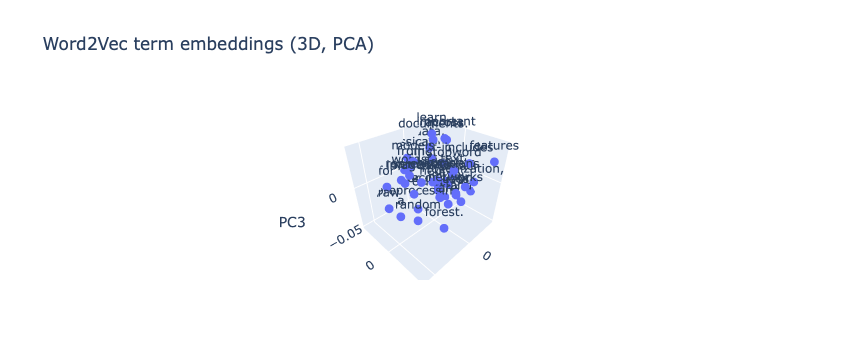

In [5]:
# %pip install -q gensim plotly scikit-learn

from gensim.models import Word2Vec
from collections import Counter
from sklearn.decomposition import PCA
import numpy as np
import plotly.graph_objects as go

# Tokenisation très simple :
corpus_tokens = [[w.lower() for w in doc.split()] for doc in docs]

# --- Entraîner un petit Word2Vec ---
w2v = Word2Vec(
    sentences=corpus_tokens,
    vector_size=50, window=5, min_count=1, workers=4, seed=42
)

# --- Sélectionner les mots à afficher (top-N par fréquence) ---
freq = Counter([w for doc in corpus_tokens for w in doc])
vocab_sorted = [w for w, _ in freq.most_common(80)]  # top 80 (ajuste selon ton corpus)
# Garder uniquement ceux connus par le modèle
words = [w for w in vocab_sorted if w in w2v.wv.key_to_index]

# Si trop peu de mots, fais un fallback
assert len(words) >= 5, "Pas assez de mots pour tracer — ajoute des textes."

# --- Matrice d'embeddings ---
X = np.vstack([w2v.wv[w] for w in words])  # shape: (n_words, dim)

# --- Réduction en 3D (PCA rapide) ---
coords3d = PCA(n_components=3, random_state=42).fit_transform(X)

# --- Plot 3D Plotly ---
fig = go.Figure(data=[go.Scatter3d(
    x=coords3d[:,0], y=coords3d[:,1], z=coords3d[:,2],
    mode='markers+text',
    text=words,
    textposition="top center",
    marker=dict(size=5)
)])
fig.update_layout(
    title="Word2Vec term embeddings (3D, PCA)",
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3")
)
fig.show()


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Shape: (5, 384)


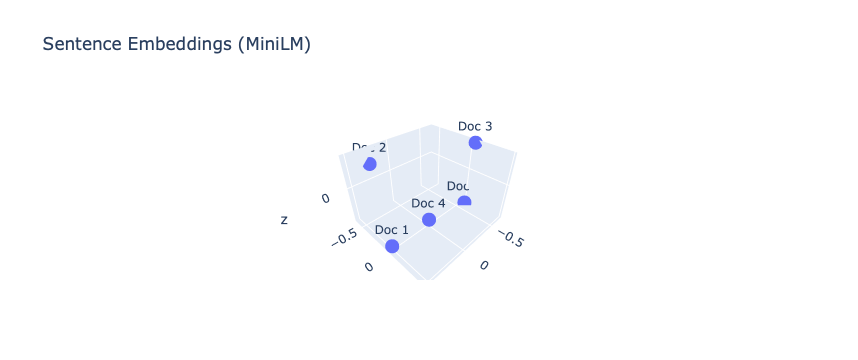

In [6]:
# %uv add sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Embedding des phrases
doc_embeddings = model.encode(docs, show_progress_bar=False)

print("Shape:", doc_embeddings.shape)  # (n_docs, 384)

# Projection 3D
from sklearn.decomposition import PCA
import plotly.express as px

emb_3d = PCA(n_components=3).fit_transform(doc_embeddings)

fig = px.scatter_3d(
    x=emb_3d[:,0], y=emb_3d[:,1], z=emb_3d[:,2],
    text=labels, title="Sentence Embeddings (MiniLM)"
)
fig.show()
